# Men vs Women Drivers — The Ultimate Showdown

This notebook builds on the fatal-occupant breakdown from `gender_angle_analysis.ipynb` and broadens it into a head-to-head comparison of **male and female drivers** across the entire NYC crash dataset — not just fatal incidents.

The questions we answer:

1. **Who's behind the wheel?** — sex breakdown of drivers in crashes
2. **How bad are their crashes?** — severity composition (property-only / injury / fatal)
3. **What gets blamed on them?** — contributing factors
4. **What were they doing?** — pre-crash maneuver
5. **What do they drive?** — vehicle type
6. **When do they crash?** — hour of day & day of week
7. **Where do they crash?** — borough patterns
8. **Who pays the price?** — pedestrian / cyclist / motorist deaths in their crashes
9. **The verdict** — final scorecard

> **Caveat.** NYC OpenData has no population baseline of how many M vs F drivers hold licenses, so we can't compute true per-capita rates. Instead we compare *within-sex proportions* and *severity rates per driver-crash* so the M:F sample-size imbalance doesn't drown the female signal.


In [1]:
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Style consistent with the rest of the project --- #
MALE_C = plt.cm.plasma(0.25)
FEMALE_C = plt.cm.plasma(0.70)
plt.rcParams["axes.titleweight"] = "bold"


In [2]:
# --- Crash-level (1 row per collision) --- #
crash_df = pd.read_parquet("datasets/crash_data.parquet", engine="pyarrow")[[
    "COLLISION_ID", "BOROUGH", "CRASH DATETIME",
    "NUMBER OF PERSONS INJURED", "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED", "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]].rename(columns={"CRASH DATETIME": "CRASH_DATETIME"})

# --- Vehicle-level (1 row per driver-in-a-crash) --- #
veh = pd.read_csv(
    "datasets/Motor_Vehicle_Collisions_-_Vehicles_20260424.csv",
    usecols=[
        "COLLISION_ID", "DRIVER_SEX", "VEHICLE_TYPE",
        "CONTRIBUTING_FACTOR_1", "PRE_CRASH",
    ],
)
veh = veh[veh["DRIVER_SEX"].isin(["M", "F"])].copy()
veh["DRIVER_SEX"] = veh["DRIVER_SEX"].astype("category")

# --- Join: one row per known-sex driver, with their crash's outcome --- #
drv = veh.merge(crash_df, on="COLLISION_ID", how="inner")

# Crash severity bucket per driver-row (vectorized; nullable Int8-safe)
killed = drv["NUMBER OF PERSONS KILLED"].fillna(0).astype("int32")
injured = drv["NUMBER OF PERSONS INJURED"].fillna(0).astype("int32")
drv["SEVERITY"] = pd.Categorical(
    np.where(killed > 0, "Fatal",
             np.where(injured > 0, "Injury", "Property only")),
    categories=["Property only", "Injury", "Fatal"],
)

print(f"Driver-rows with known sex: {len(drv):,}")
print(drv["DRIVER_SEX"].value_counts())


Driver-rows with known sex: 1,955,223
DRIVER_SEX
M    1457017
F     498206
Name: count, dtype: int64


## 1. Who's behind the wheel?

Before any comparisons, the raw counts. Every later proportion is computed *within each sex* so this imbalance doesn't drive the story.


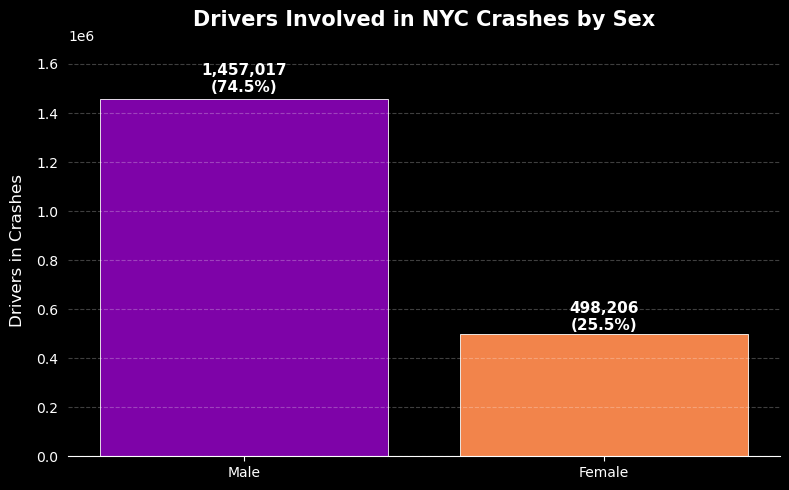

Sample imbalance: 2.92× more male drivers than female.


In [3]:
counts = drv["DRIVER_SEX"].value_counts().reindex(["M", "F"])
shares = counts / counts.sum() * 100

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        ["Male", "Female"], counts.values,
        color=[MALE_C, FEMALE_C], edgecolor="white", linewidth=0.6,
    )
    for bar, s in zip(bars, shares.values):
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h * 1.01,
            f"{int(h):,}\n({s:.1f}%)",
            ha="center", va="bottom",
            fontsize=11, color="white", fontweight="bold",
        )
    ax.set_ylabel("Drivers in Crashes", fontsize=12, labelpad=8)
    ax.set_title("Drivers Involved in NYC Crashes by Sex", fontsize=15, pad=14)
    ax.set_ylim(0, counts.max() * 1.15)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    plt.tight_layout()
    plt.show()

print(f"Sample imbalance: {counts['M'] / counts['F']:.2f}× more male drivers than female.")


## 2. How bad are their crashes?

Severity bucket per driver-row:

- **Property only** — nobody injured or killed
- **Injury** — at least one person injured, none killed
- **Fatal** — at least one person killed

We compare the *composition within each sex* — i.e. of all male drivers, what fraction were in a fatal crash, vs the same for women.


In [4]:
sev_order = ["Property only", "Injury", "Fatal"]
sev_ct = (
    drv.groupby(["DRIVER_SEX", "SEVERITY"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=["M", "F"], columns=sev_order)
)
sev_pct = sev_ct.div(sev_ct.sum(axis=1), axis=0) * 100

print("Counts:\n", sev_ct, "\n")
print("Within-sex %:\n", sev_pct.round(2))


Counts:
 SEVERITY    Property only  Injury  Fatal
DRIVER_SEX                              
M                 1008717  445692   2608
F                  350238  147544    424 

Within-sex %:
 SEVERITY    Property only  Injury  Fatal
DRIVER_SEX                              
M                   69.23   30.59   0.18
F                   70.30   29.62   0.09


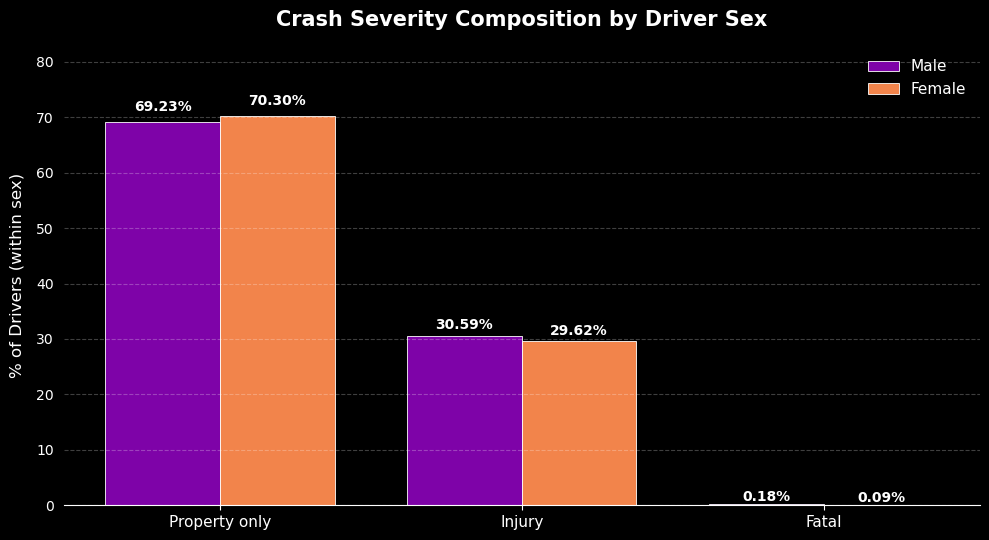

Fatal-crash share — M: 0.179%  F: 0.085%  → M is 2.10× higher
Injury-crash share — M: 30.59%  F: 29.62%  → ratio 1.03×


In [5]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    x = np.arange(len(sev_order))
    w = 0.38

    bars_m = ax.bar(x - w/2, sev_pct.loc["M"], w, label="Male",
                    color=MALE_C, edgecolor="white", linewidth=0.6)
    bars_f = ax.bar(x + w/2, sev_pct.loc["F"], w, label="Female",
                    color=FEMALE_C, edgecolor="white", linewidth=0.6)

    for bars in (bars_m, bars_f):
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h * 1.02,
                    f"{h:.2f}%", ha="center", va="bottom",
                    fontsize=10, color="white", fontweight="bold")

    ax.set_xticks(x); ax.set_xticklabels(sev_order, fontsize=11)
    ax.set_ylabel("% of Drivers (within sex)", fontsize=12, labelpad=8)
    ax.set_title("Crash Severity Composition by Driver Sex", fontsize=15, pad=14)
    ax.set_ylim(0, sev_pct.values.max() * 1.18)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    ax.legend(frameon=False, fontsize=11, loc="upper right")
    plt.tight_layout()
    plt.show()

# Headline ratio
m_fatal = sev_pct.loc["M", "Fatal"]; f_fatal = sev_pct.loc["F", "Fatal"]
m_inj = sev_pct.loc["M", "Injury"]; f_inj = sev_pct.loc["F", "Injury"]
print(f"Fatal-crash share — M: {m_fatal:.3f}%  F: {f_fatal:.3f}%  → M is {m_fatal/f_fatal:.2f}× higher")
print(f"Injury-crash share — M: {m_inj:.2f}%  F: {f_inj:.2f}%  → ratio {m_inj/f_inj:.2f}×")


## 3. What gets blamed on them?

`CONTRIBUTING_FACTOR_1` is the police officer's primary attribution per vehicle. We drop `Unspecified` and `NaN` (no factor recorded) and look at the **share of attributed-factor drivers** within each sex — so the comparison is apples to apples.


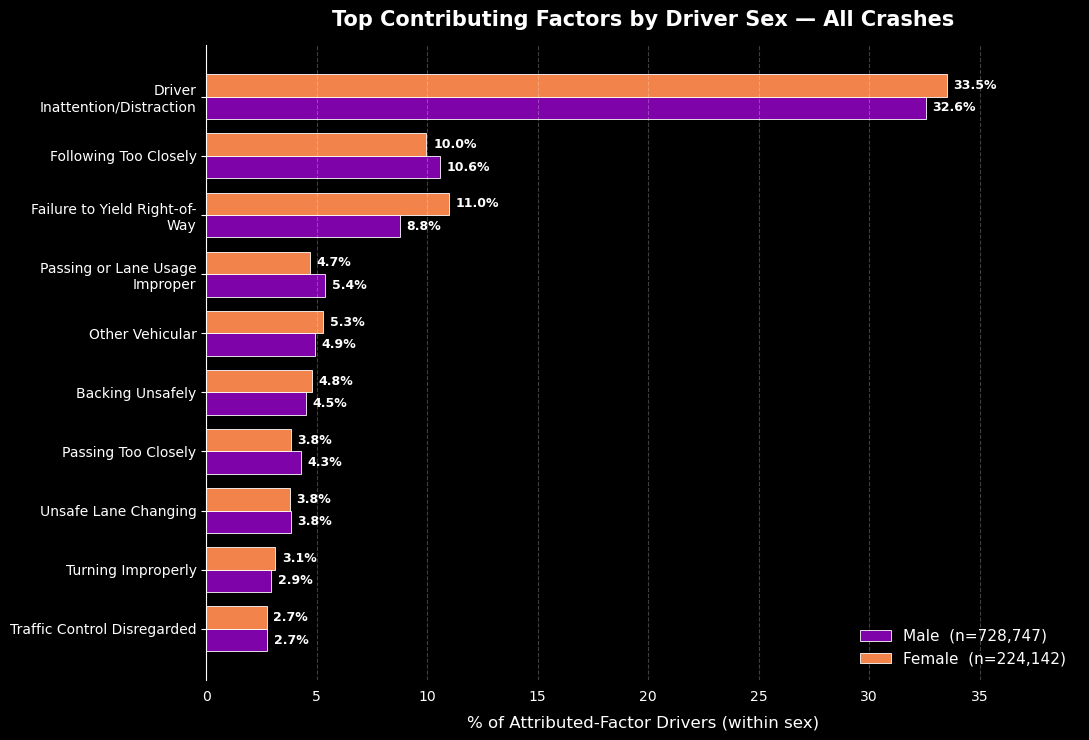

Largest male-skewed factors (M% − F%):
CONTRIBUTING_FACTOR_1
Passing or Lane Usage Improper    0.68
Following Too Closely             0.61
Passing Too Closely               0.44

Largest female-skewed factors (F% − M%):
CONTRIBUTING_FACTOR_1
Failure to Yield Right-of-Way     2.24
Driver Inattention/Distraction    0.94
Other Vehicular                   0.39


In [6]:
cf = drv[drv["CONTRIBUTING_FACTOR_1"].notna()
         & (drv["CONTRIBUTING_FACTOR_1"] != "Unspecified")].copy()

top = cf["CONTRIBUTING_FACTOR_1"].value_counts().head(10).index.tolist()

ct = (
    cf[cf["CONTRIBUTING_FACTOR_1"].isin(top)]
    .groupby(["CONTRIBUTING_FACTOR_1", "DRIVER_SEX"], observed=True)
    .size()
    .unstack(fill_value=0)
    .loc[top, ["M", "F"]]
)
totals = cf.groupby("DRIVER_SEX", observed=True).size()
prop = ct.div(totals[["M", "F"]], axis=1) * 100

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(11, 7.5))
    y = np.arange(len(top)); h = 0.38
    labels = [textwrap.fill(f, 28) for f in top]

    bars_m = ax.barh(y + h/2, prop["M"], h,
                     label=f"Male  (n={int(totals['M']):,})",
                     color=MALE_C, edgecolor="white", linewidth=0.6)
    bars_f = ax.barh(y - h/2, prop["F"], h,
                     label=f"Female  (n={int(totals['F']):,})",
                     color=FEMALE_C, edgecolor="white", linewidth=0.6)
    for bars in (bars_m, bars_f):
        for b in bars:
            w = b.get_width()
            ax.text(w + 0.3, b.get_y() + b.get_height()/2,
                    f"{w:.1f}%", va="center", ha="left",
                    fontsize=9, color="white", fontweight="bold")

    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("% of Attributed-Factor Drivers (within sex)", fontsize=12, labelpad=8)
    ax.set_title("Top Contributing Factors by Driver Sex — All Crashes",
                 fontsize=15, pad=14)
    ax.set_xlim(0, prop.values.max() * 1.18)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    for s in ("top", "right", "bottom"):
        ax.spines[s].set_visible(False)
    ax.tick_params(bottom=False)
    ax.legend(frameon=False, fontsize=11, loc="lower right")
    plt.tight_layout()
    plt.show()

# Differential — where the M and F bars diverge most
diff = (prop["M"] - prop["F"]).sort_values(ascending=False)
print("Largest male-skewed factors (M% − F%):")
print(diff.head(3).round(2).to_string())
print("\nLargest female-skewed factors (F% − M%):")
print((-diff).sort_values(ascending=False).head(3).round(2).to_string())


## 4. What were they doing before the crash?

`PRE_CRASH` records the maneuver each driver was performing immediately before impact — going straight, turning, backing, parked, and so on. This is closer to "driving behaviour" than the after-the-fact contributing factor.


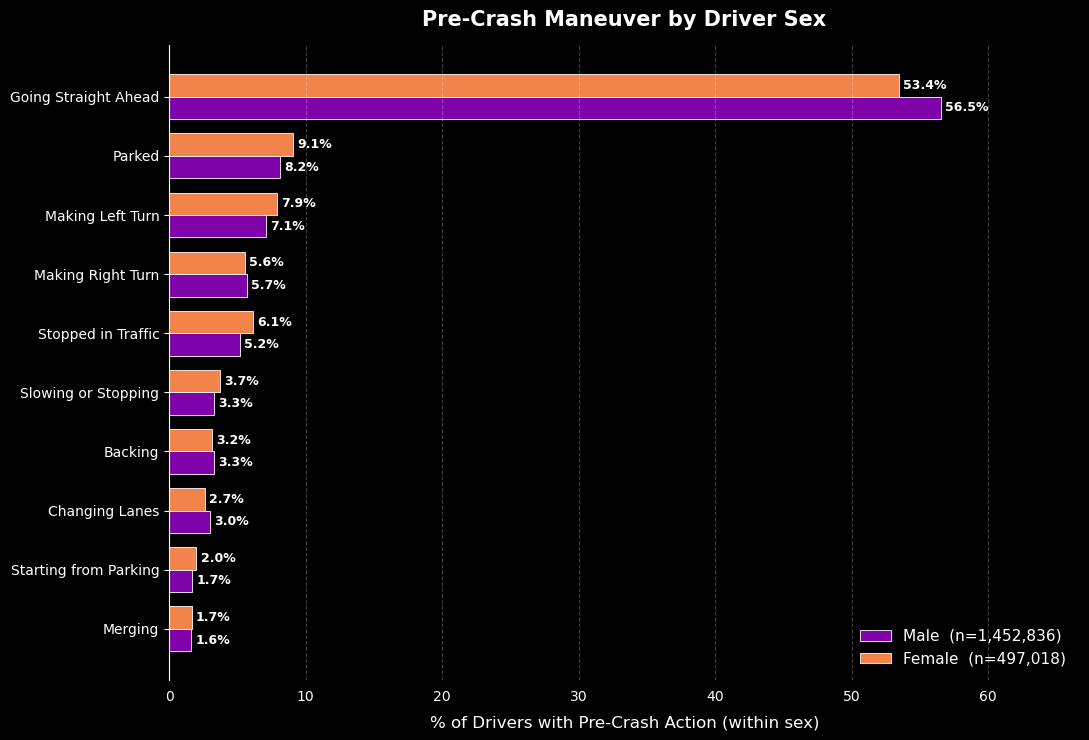

In [7]:
pc = drv[drv["PRE_CRASH"].notna() & (drv["PRE_CRASH"] != "Unknown")].copy()

top_pc = pc["PRE_CRASH"].value_counts().head(10).index.tolist()
ct_pc = (
    pc[pc["PRE_CRASH"].isin(top_pc)]
    .groupby(["PRE_CRASH", "DRIVER_SEX"], observed=True)
    .size()
    .unstack(fill_value=0)
    .loc[top_pc, ["M", "F"]]
)
tot_pc = pc.groupby("DRIVER_SEX", observed=True).size()
prop_pc = ct_pc.div(tot_pc[["M", "F"]], axis=1) * 100

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(11, 7.5))
    y = np.arange(len(top_pc)); h = 0.38
    labels = [textwrap.fill(f, 28) for f in top_pc]

    ax.barh(y + h/2, prop_pc["M"], h,
            label=f"Male  (n={int(tot_pc['M']):,})",
            color=MALE_C, edgecolor="white", linewidth=0.6)
    ax.barh(y - h/2, prop_pc["F"], h,
            label=f"Female  (n={int(tot_pc['F']):,})",
            color=FEMALE_C, edgecolor="white", linewidth=0.6)

    for sex, off in [("M", h/2), ("F", -h/2)]:
        for yi, v in zip(y, prop_pc[sex]):
            ax.text(v + 0.3, yi + off, f"{v:.1f}%",
                    va="center", ha="left",
                    fontsize=9, color="white", fontweight="bold")

    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("% of Drivers with Pre-Crash Action (within sex)",
                  fontsize=12, labelpad=8)
    ax.set_title("Pre-Crash Maneuver by Driver Sex", fontsize=15, pad=14)
    ax.set_xlim(0, prop_pc.values.max() * 1.18)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    for s in ("top", "right", "bottom"):
        ax.spines[s].set_visible(False)
    ax.tick_params(bottom=False)
    ax.legend(frameon=False, fontsize=11, loc="lower right")
    plt.tight_layout()
    plt.show()


## 5. What do they drive?

Vehicle-type composition. Useful context for everything that follows: a sex skew on motorcycle or truck driving will pull through into severity and injury patterns.


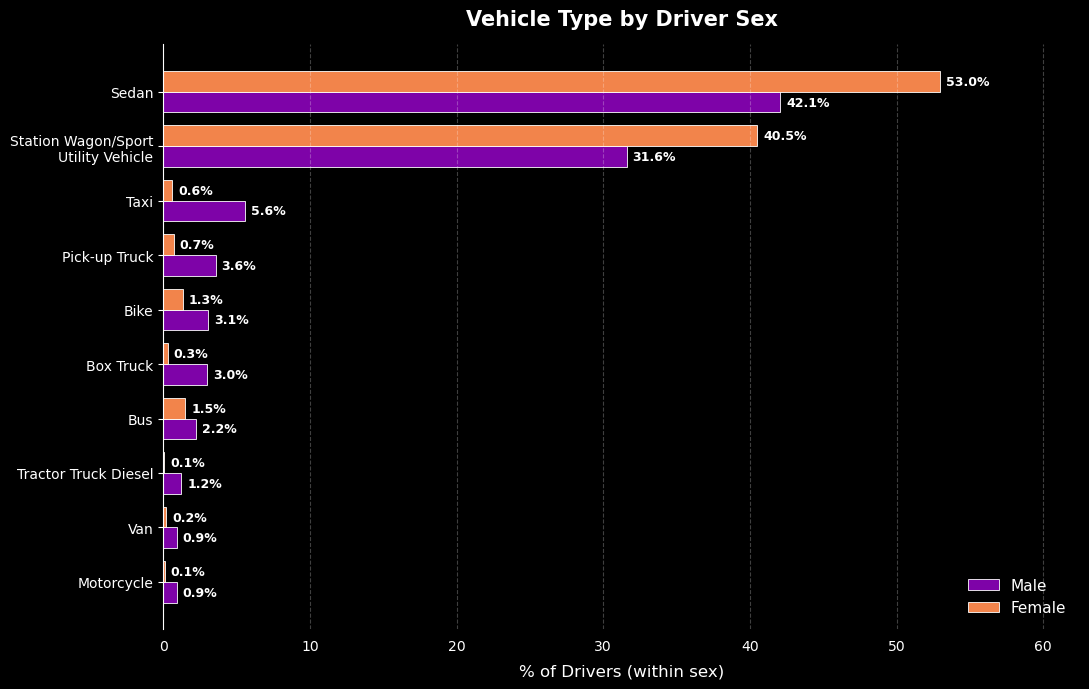

In [8]:
# Light normalization — collapse a few near-duplicate labels
vmap = {
    "4 dr sedan": "Sedan",
    "2 dr sedan": "Sedan",
}
drv["VEHICLE_TYPE_NORM"] = drv["VEHICLE_TYPE"].replace(vmap)

vt = drv[drv["VEHICLE_TYPE_NORM"].notna()].copy()
top_vt = vt["VEHICLE_TYPE_NORM"].value_counts().head(10).index.tolist()
ct_v = (
    vt[vt["VEHICLE_TYPE_NORM"].isin(top_vt)]
    .groupby(["VEHICLE_TYPE_NORM", "DRIVER_SEX"], observed=True)
    .size()
    .unstack(fill_value=0)
    .loc[top_vt, ["M", "F"]]
)
tot_v = vt.groupby("DRIVER_SEX", observed=True).size()
prop_v = ct_v.div(tot_v[["M", "F"]], axis=1) * 100

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(11, 7))
    y = np.arange(len(top_vt)); h = 0.38
    labels = [textwrap.fill(f, 24) for f in top_vt]

    ax.barh(y + h/2, prop_v["M"], h, label="Male",
            color=MALE_C, edgecolor="white", linewidth=0.6)
    ax.barh(y - h/2, prop_v["F"], h, label="Female",
            color=FEMALE_C, edgecolor="white", linewidth=0.6)

    for sex, off in [("M", h/2), ("F", -h/2)]:
        for yi, v in zip(y, prop_v[sex]):
            ax.text(v + 0.4, yi + off, f"{v:.1f}%",
                    va="center", ha="left",
                    fontsize=9, color="white", fontweight="bold")

    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("% of Drivers (within sex)", fontsize=12, labelpad=8)
    ax.set_title("Vehicle Type by Driver Sex", fontsize=15, pad=14)
    ax.set_xlim(0, prop_v.values.max() * 1.18)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    for s in ("top", "right", "bottom"):
        ax.spines[s].set_visible(False)
    ax.tick_params(bottom=False)
    ax.legend(frameon=False, fontsize=11, loc="lower right")
    plt.tight_layout()
    plt.show()


## 6. When do they crash?

Two views:
- **Hour of day** — does the male-skew widen at night?
- **Day of week** — weekday vs weekend


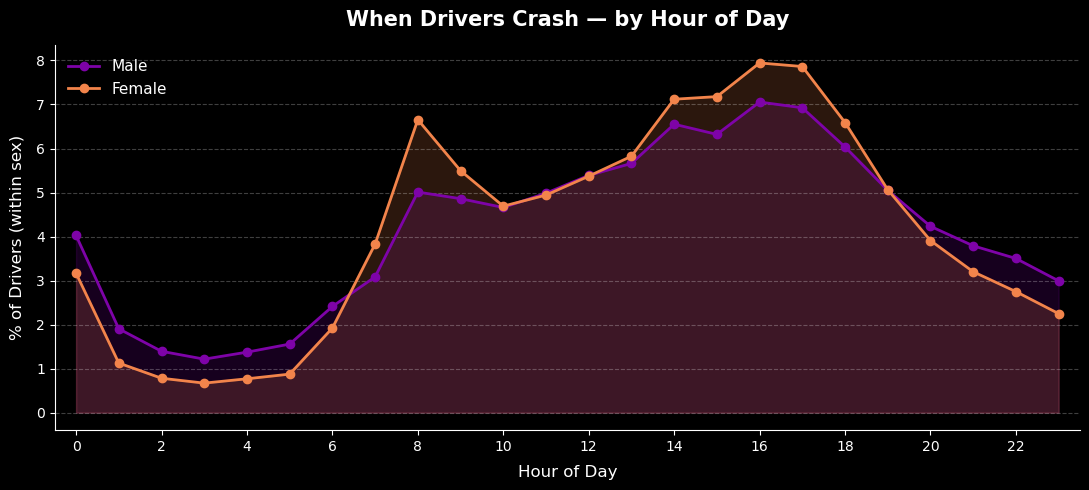

Share of each sex's crashes that happen 00:00–04:59:
  M: 9.92%   F: 6.52%   ratio: 1.52×


In [9]:
drv["HOUR"] = drv["CRASH_DATETIME"].dt.hour
drv["DOW"] = drv["CRASH_DATETIME"].dt.dayofweek  # 0 = Mon

# --- Hour of day, normalized within sex --- #
hr = (drv.groupby(["HOUR", "DRIVER_SEX"], observed=True).size()
        .unstack(fill_value=0).reindex(range(24), fill_value=0))
hr_pct = hr.div(hr.sum(axis=0), axis=1) * 100

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(hr_pct.index, hr_pct["M"], marker="o", color=MALE_C, label="Male", linewidth=2)
    ax.plot(hr_pct.index, hr_pct["F"], marker="o", color=FEMALE_C, label="Female", linewidth=2)
    ax.fill_between(hr_pct.index, hr_pct["M"], color=MALE_C, alpha=0.18)
    ax.fill_between(hr_pct.index, hr_pct["F"], color=FEMALE_C, alpha=0.18)
    ax.set_xticks(range(0, 24, 2)); ax.set_xlim(-0.5, 23.5)
    ax.set_xlabel("Hour of Day", fontsize=12, labelpad=8)
    ax.set_ylabel("% of Drivers (within sex)", fontsize=12, labelpad=8)
    ax.set_title("When Drivers Crash — by Hour of Day", fontsize=15, pad=14)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.legend(frameon=False, fontsize=11, loc="upper left")
    plt.tight_layout(); plt.show()

# Late-night skew (00–04)
night = drv[drv["HOUR"].isin([0, 1, 2, 3, 4])]
ns = night["DRIVER_SEX"].value_counts() / drv["DRIVER_SEX"].value_counts() * 100
print(f"Share of each sex's crashes that happen 00:00–04:59:")
print(f"  M: {ns['M']:.2f}%   F: {ns['F']:.2f}%   ratio: {ns['M']/ns['F']:.2f}×")


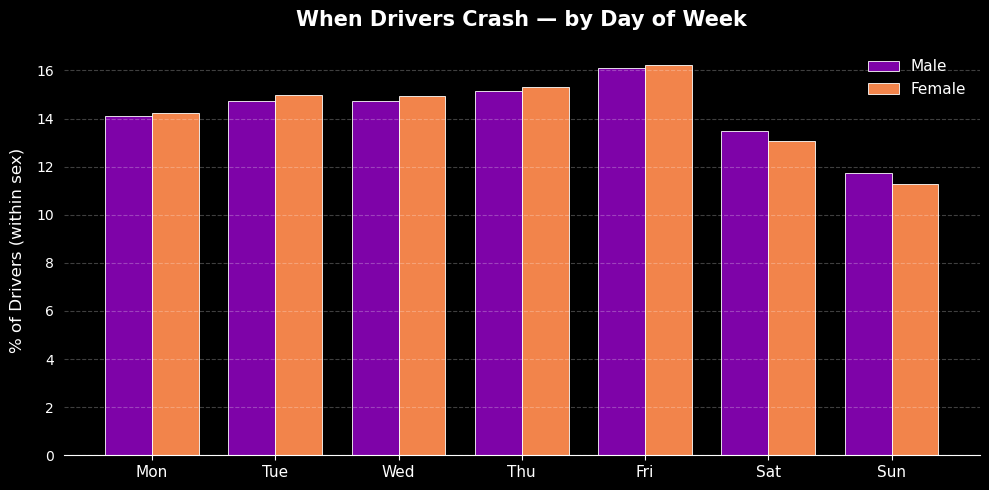

In [10]:
# --- Day of week, normalized within sex --- #
dow = (drv.groupby(["DOW", "DRIVER_SEX"], observed=True).size()
         .unstack(fill_value=0).reindex(range(7), fill_value=0))
dow_pct = dow.div(dow.sum(axis=0), axis=1) * 100
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(7); w = 0.38
    ax.bar(x - w/2, dow_pct["M"], w, label="Male",
           color=MALE_C, edgecolor="white", linewidth=0.6)
    ax.bar(x + w/2, dow_pct["F"], w, label="Female",
           color=FEMALE_C, edgecolor="white", linewidth=0.6)
    ax.set_xticks(x); ax.set_xticklabels(day_labels, fontsize=11)
    ax.set_ylabel("% of Drivers (within sex)", fontsize=12, labelpad=8)
    ax.set_title("When Drivers Crash — by Day of Week", fontsize=15, pad=14)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    ax.legend(frameon=False, fontsize=11, loc="upper right")
    plt.tight_layout(); plt.show()


## 7. Where do they crash?

Borough composition within each sex.


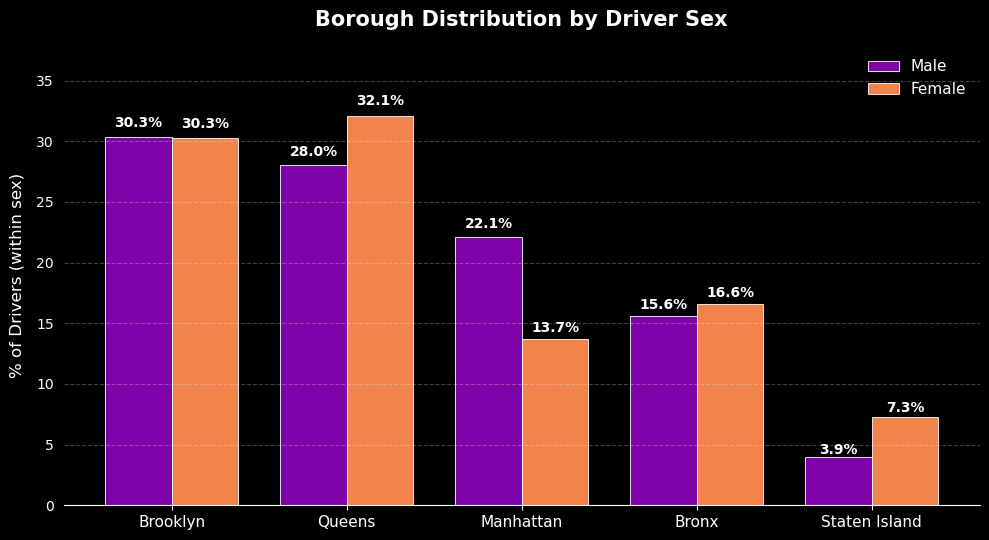

In [11]:
boro = (drv[drv["BOROUGH"].notna() & (drv["BOROUGH"] != "")]
        .groupby(["BOROUGH", "DRIVER_SEX"], observed=True).size()
        .unstack(fill_value=0)[["M", "F"]])
boro = boro.loc[boro.sum(axis=1).sort_values(ascending=False).index]
boro_pct = boro.div(boro.sum(axis=0), axis=1) * 100

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    x = np.arange(len(boro_pct)); w = 0.38
    bars_m = ax.bar(x - w/2, boro_pct["M"], w, label="Male",
                    color=MALE_C, edgecolor="white", linewidth=0.6)
    bars_f = ax.bar(x + w/2, boro_pct["F"], w, label="Female",
                    color=FEMALE_C, edgecolor="white", linewidth=0.6)
    for bars in (bars_m, bars_f):
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h * 1.02,
                    f"{h:.1f}%", ha="center", va="bottom",
                    fontsize=10, color="white", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(boro_pct.index, fontsize=11)
    ax.set_ylabel("% of Drivers (within sex)", fontsize=12, labelpad=8)
    ax.set_title("Borough Distribution by Driver Sex", fontsize=15, pad=14)
    ax.set_ylim(0, boro_pct.values.max() * 1.18)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    ax.legend(frameon=False, fontsize=11, loc="upper right")
    plt.tight_layout(); plt.show()


## 8. Who pays the price?

When a driver of each sex is in a fatal crash, who's the one who dies — pedestrian, cyclist, or motorist? This is the *outcome* lens: it doesn't necessarily mean the driver was at fault, just that they were in the crash.


In [12]:
# Drivers in fatal crashes only
fatal_drv = drv[drv["SEVERITY"] == "Fatal"].copy()

# Sum victim counts attributed to each driver-row (will double-count multi-driver crashes,
# but that double-count is symmetric across sex except where mixed-sex crashes occur).
victims = (
    fatal_drv.groupby("DRIVER_SEX", observed=True)[
        ["NUMBER OF PEDESTRIANS KILLED",
         "NUMBER OF CYCLIST KILLED",
         "NUMBER OF MOTORIST KILLED"]
    ].sum().rename(columns={
        "NUMBER OF PEDESTRIANS KILLED": "Pedestrian",
        "NUMBER OF CYCLIST KILLED": "Cyclist",
        "NUMBER OF MOTORIST KILLED": "Motorist",
    }).reindex(["M", "F"])
)
victims_pct = victims.div(victims.sum(axis=1), axis=0) * 100

print("Victim counts (in fatal crashes by driver sex):\n", victims, "\n")
print("% composition within sex:\n", victims_pct.round(2))


Victim counts (in fatal crashes by driver sex):
             Pedestrian  Cyclist  Motorist
DRIVER_SEX                               
M                  977      355      1379
F                  161       51       220 

% composition within sex:
             Pedestrian  Cyclist  Motorist
DRIVER_SEX                               
M                36.04    13.09     50.87
F                37.27    11.81     50.93


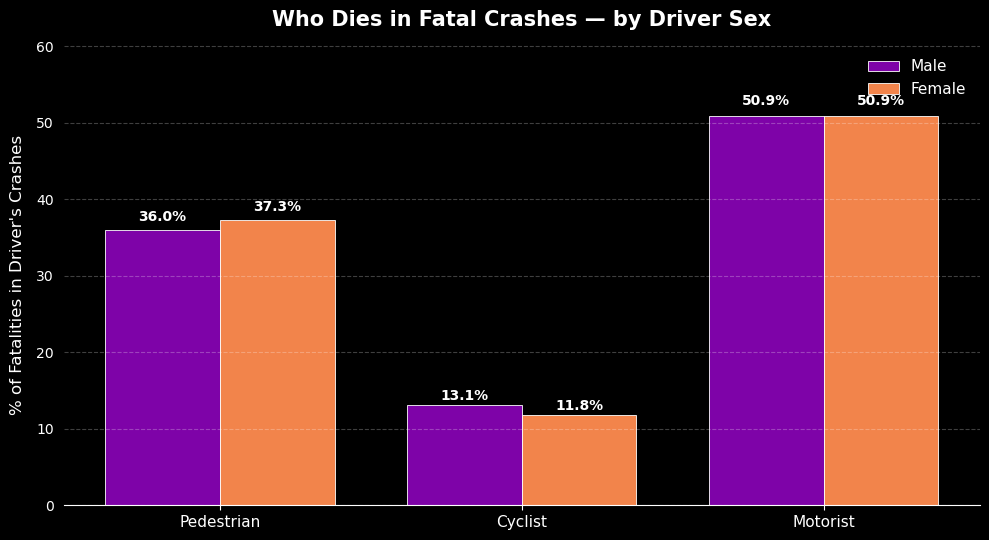

In [13]:
cats = ["Pedestrian", "Cyclist", "Motorist"]

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    x = np.arange(len(cats)); w = 0.38
    bars_m = ax.bar(x - w/2, victims_pct.loc["M", cats], w, label="Male",
                    color=MALE_C, edgecolor="white", linewidth=0.6)
    bars_f = ax.bar(x + w/2, victims_pct.loc["F", cats], w, label="Female",
                    color=FEMALE_C, edgecolor="white", linewidth=0.6)
    for bars in (bars_m, bars_f):
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h * 1.02,
                    f"{h:.1f}%", ha="center", va="bottom",
                    fontsize=10, color="white", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=11)
    ax.set_ylabel("% of Fatalities in Driver's Crashes", fontsize=12, labelpad=8)
    ax.set_title("Who Dies in Fatal Crashes — by Driver Sex", fontsize=15, pad=14)
    ax.set_ylim(0, victims_pct.values.max() * 1.18)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    ax.legend(frameon=False, fontsize=11, loc="upper right")
    plt.tight_layout(); plt.show()


## 9. The verdict

A small scorecard pulling the key ratios into one frame. Each row is a single number from above, expressed as **(Male rate) ÷ (Female rate)** — values above 1.0 mean men over-index on that dimension; below 1.0 means women do.


In [14]:
# Helper: rate of M divided by rate of F for a given binary outcome on the driver-row level
def m_over_f(mask):
    rates = drv.assign(_x=mask.astype(int)).groupby("DRIVER_SEX", observed=True)["_x"].mean()
    return rates["M"] / rates["F"], rates["M"] * 100, rates["F"] * 100

scorecard = []

ratio, mr, fr = m_over_f(drv["SEVERITY"] == "Fatal")
scorecard.append(("In a fatal crash", mr, fr, ratio))

ratio, mr, fr = m_over_f(drv["SEVERITY"] == "Injury")
scorecard.append(("In an injury crash", mr, fr, ratio))

ratio, mr, fr = m_over_f(
    drv["CONTRIBUTING_FACTOR_1"].notna()
    & (drv["CONTRIBUTING_FACTOR_1"] != "Unspecified")
)
scorecard.append(("Has a recorded fault factor", mr, fr, ratio))

for fac in ["Driver Inattention/Distraction", "Following Too Closely",
            "Failure to Yield Right-of-Way", "Backing Unsafely",
            "Unsafe Speed", "Alcohol Involvement"]:
    if (drv["CONTRIBUTING_FACTOR_1"] == fac).any():
        ratio, mr, fr = m_over_f(drv["CONTRIBUTING_FACTOR_1"] == fac)
        scorecard.append((f"Cited: {fac}", mr, fr, ratio))

ratio, mr, fr = m_over_f(drv["HOUR"].isin([0, 1, 2, 3, 4]))
scorecard.append(("Crash 00:00–04:59", mr, fr, ratio))

ratio, mr, fr = m_over_f(drv["VEHICLE_TYPE"] == "Motorcycle")
scorecard.append(("Driving a motorcycle", mr, fr, ratio))

sc = pd.DataFrame(scorecard, columns=["Dimension", "Male %", "Female %", "M/F ratio"])
sc = sc.sort_values("M/F ratio", ascending=True).reset_index(drop=True)
sc


,Dimension,Male %,Female %,M/F ratio
0,Cited: Failure to Yield Right-of-Way,4.377300,4.945946,0.885028
1,In an injury crash,30.589348,29.615059,1.032898
2,Cited: Backing Unsafely,2.252273,2.146100,1.049472
3,Cited: Driver Inattention/Distraction,16.291505,15.076093,1.080619
4,Has a recorded fault factor,50.016369,44.989823,1.111726
5,Cited: Following Too Closely,5.289094,4.482684,1.179895
6,Crash 00:00–04:59,9.916357,6.518990,1.521149
7,Cited: Alcohol Involvement,0.995253,0.583092,1.706853
8,Cited: Unsafe Speed,1.339586,0.730220,1.834497
9,In a fatal crash,0.178996,0.085105,2.103227


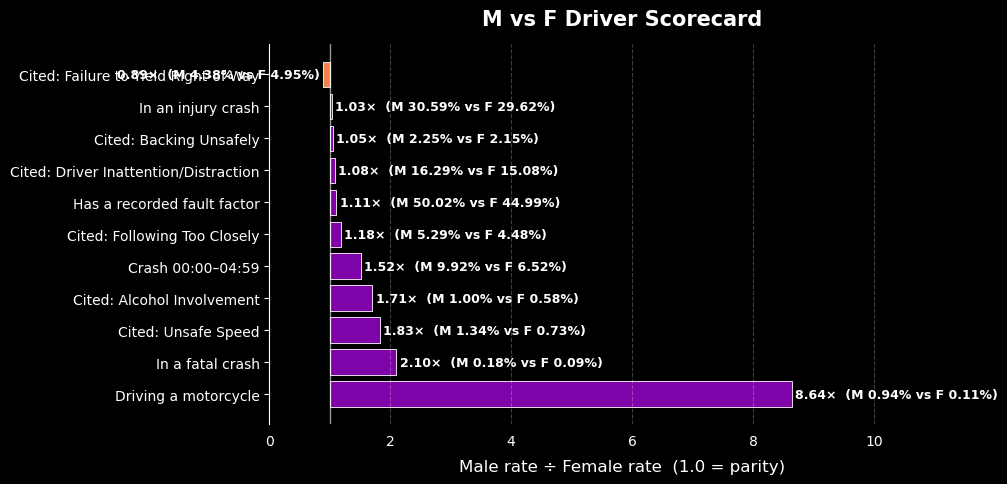

In [15]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(sc))))
    y = np.arange(len(sc))
    colors = [MALE_C if r >= 1 else FEMALE_C for r in sc["M/F ratio"]]
    ax.barh(y, sc["M/F ratio"] - 1, left=1, color=colors,
            edgecolor="white", linewidth=0.6)
    ax.axvline(1.0, color="white", linewidth=1, alpha=0.6)

    for yi, (lab, mr, fr, r) in enumerate(sc.itertuples(index=False)):
        ax.text(r + 0.05 if r >= 1 else r - 0.05, yi,
                f"{r:.2f}×  (M {mr:.2f}% vs F {fr:.2f}%)",
                va="center", ha="left" if r >= 1 else "right",
                fontsize=9, color="white", fontweight="bold")

    ax.set_yticks(y); ax.set_yticklabels(sc["Dimension"], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Male rate ÷ Female rate  (1.0 = parity)", fontsize=12, labelpad=8)
    ax.set_title("M vs F Driver Scorecard", fontsize=15, pad=14)
    ax.set_xlim(0, max(sc["M/F ratio"].max() * 1.35, 1.5))
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    for s in ("top", "right", "bottom"):
        ax.spines[s].set_visible(False)
    ax.tick_params(bottom=False)
    plt.tight_layout(); plt.show()


### Reading the verdict

- Bars to the **right of 1.0** are dimensions where men over-index relative to women — the bigger the bar, the bigger the gap.
- Bars to the **left of 1.0** are dimensions where women over-index.
- Numbers in parentheses are the actual within-sex rates being divided.

The headline pattern in NYC's data: men aren't just more numerous in the dataset — they over-index on **fatal-crash involvement, late-night crashes, motorcycles, and certain aggressive-driving factors** (speed, alcohol). Women's relative concentration sits in **lower-severity events and a few maneuver-error categories** (e.g. backing). The overall picture lines up with the broader literature on sex-and-risk in road safety, but everything here is conditional on *being in a crash* — we cannot speak to per-licensed-driver rates without a population denominator.
